<a href="https://colab.research.google.com/github/MariaAkterKhadiza/deep_learning_7th-semeter/blob/main/image_classification_practice_labfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np


In [2]:
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2730s 16us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

In [14]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [15]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [16]:
classes = ["airplane","automobil","bird","cat","deer","dog","frog","harse","ship","truck"]

In [18]:
classes[7]

'harse'

In [19]:
def plot_sample(x,y,index):
    plt.figure(figsize = (15,2))
    plt.imshow(x_train[index])
    plt.xlabel(classes[y[index]])

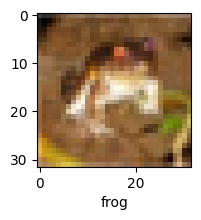

In [20]:
plot_sample(x_train,y_train,0)

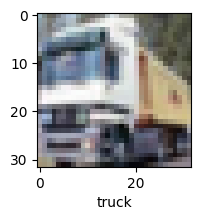

In [21]:
plot_sample(x_train,y_train,1)

**normalization**

In [22]:
x_train = x_train / 255.0
x_test = x_test / 255.0

**Build simple artificial neural network for image classification**

In [24]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(x_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 221s 141ms/step - accuracy: 0.3524 - loss: 1.8145
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 246s 131ms/step - accuracy: 0.4270 - loss: 1.6239
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 105ms/step - accuracy: 0.4547 - loss: 1.5436
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 102ms/step - accuracy: 0.4793 - loss: 1.4817
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 92ms/step - accuracy: 0.4958 - loss: 1.4342


In [27]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.63      0.49      0.55      1000
           1       0.48      0.74      0.58      1000
           2       0.53      0.15      0.23      1000
           3       0.30      0.39      0.34      1000
           4       0.52      0.30      0.38      1000
           5       0.38      0.41      0.39      1000
           6       0.43      0.69      0.53      1000
           7       0.53      0.55      0.54      1000
           8       0.72      0.43      0.53      1000
           9       0.48      0.56      0.52      1000

    accuracy                           0.47     10000
   macro avg       0.50      0.47      0.46     10000
weighted avg       0.50      0.47      0.46     10000




**Now let us build a convolutional neural network to train our images**

In [30]:
from tensorflow.keras import models, layers

cnn = models.Sequential([
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
cnn.compile(optimizer = 'adam',
            loss = 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])


In [33]:

cnn.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 43ms/step - accuracy: 0.4686 - loss: 1.4748
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6083 - loss: 1.1218
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6578 - loss: 0.9843
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.6890 - loss: 0.8932
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7145 - loss: 0.8207
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7336 - loss: 0.7685
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7488 - loss: 0.7203
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7672 - loss: 0.6678
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.7797 - loss: 0.6270
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7930 - loss: 0.5937


In [35]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6876 - loss: 0.9794


[0.9794117212295532, 0.6876000165939331]

In [36]:
y_pred = cnn.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[1.78490928e-03, 7.69608538e-04, 2.06954079e-03, 8.09467196e-01,
        1.29098981e-03, 1.56614840e-01, 1.25177680e-02, 4.14676833e-05,
        1.36081269e-02, 1.83545460e-03],
       [1.71049312e-03, 3.11489105e-02, 2.18702155e-07, 4.07142835e-07,
        2.10580087e-09, 8.81617224e-10, 3.58173102e-10, 5.19289278e-10,
        9.67090249e-01, 4.98028567e-05],
       [3.94088067e-02, 6.94713295e-02, 5.60156419e-04, 1.39682507e-03,
        9.05980763e-04, 1.24147482e-04, 5.24691859e-05, 3.73752206e-04,
        8.40780556e-01, 4.69258837e-02],
       [8.89107585e-01, 7.02521391e-03, 2.46039033e-03, 2.56763189e-04,
        4.39775940e-05, 2.88451020e-06, 3.33152457e-05, 2.46201080e-06,
        1.00099415e-01, 9.67926113e-04],
       [1.19291911e-07, 3.96283485e-06, 3.04938830e-03, 1.77633576e-02,
        1.59038920e-02, 7.19308096e-04, 9.62536573e-01, 3.12635429e-08,
        2.33145875e-05, 7.04969025e-08]], dtype=float32)

In [37]:

y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [38]:

y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

TypeError: only integer scalar arrays can be converted to a scalar index

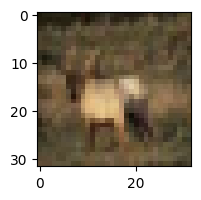

In [43]:
plot_sample(x_test, y_test, 3)

In [42]:

classes[y_classes[3]]

'airplane'